Take individual confocal overviews `.tif` images and stitch them into a big image based on `.msr` stage coordinates. 
Add spot coordinates from a list to big image. 
Add STED detail image locations to big image. 

In [ ]:
import re
import sys
import os
import numpy as np
from pathlib import Path
import pandas as pd
from glob import glob
from natsort import natsorted
from skimage.io import imread
import matplotlib.pyplot as plt
import seaborn as sns
from msr_reader import OBFFile
import tifffile as tiff
sys.path.append('/home/stumberger/image-analyis-recipes/alignment/sted/')
from transform_helpers import get_scan_field_metadata, get_scan_field_metadata_h5, world_coords_for_pixel_spots
from projection import get_orthogonal_projections_8bit
from calmutils.color import gray_images_to_rgb_composite

In [129]:
in_path = "/data/agl_data/NanoFISH/Gabi/GS485_Dppa3_all_mESC_RNA-DNA/20240727_DNAFISH/"
subdir = "tif"
raw_subpath = "raw"
exclude_string = "sted"
use_h5_for_metadata = False
global_coordinate_column_names = ['z_global_um', 'y_global_um', 'x_global_um']
stage_directions = np.array([-1, 1, 1])
ch = 0

In [3]:
# def read_msr(filepath):
#     imgs = []
#     with OBFFile(filepath) as f:
#         for idx in range(0,len(f.shapes)):
#             img = f.read_stack(idx)
#             imgs.append(img)
#         return(imgs)

def read_msr(filepath):
    imgs = []
    with OBFFile(filepath) as f:
        img = f.read_stack(ch)
        imgs.append(img)
        return(imgs)

def normalize_img(img):
    return (255 * (img - img.min()) / (img.max() - img.min())).astype(np.uint8)

In [121]:
imgs = glob(f"{in_path}/{subdir}/*.tif")
imgs = natsorted(imgs)
imgs = [img for img in imgs if exclude_string not in os.path.basename(img)]

df = pd.DataFrame(imgs,columns=["img"])
sub_dfs = []

for img_path, dfi in df.groupby("img"):

    if use_h5_for_metadata:

        # parse base name (random prefix of files)
        h5_base_name = re.match('(.*?)(_.*?_[0-9]+)+_ch.*', Path(img_path).name).group(1)
        # get acquisition index (field_X_sted_Y), drop underscores not present in H5
        h5_acquisition_name = '_'.join(map(lambda s: s.replace('_', ''), re.findall('_.*?_[0-9]+', Path(img_path).name)))

        # load metadata for current acquisition from corresponding h5 file
        h5_file = h5_base_name + '.h5'
        h5_file = Path(in_path) / raw_subpath / h5_file
        meta = get_scan_field_metadata_h5(h5_file, h5_acquisition_name)

    else:

        # get corresponding msr file
        pattern = '_ch([0-9]+)\.tif'
        # pattern = r'_aligned\.tif$'
        msr_file = re.sub(pattern, '.msr', Path(img_path).name)
        msr_file = Path(in_path) / raw_subpath / msr_file

        # get scan field metadata
        meta = get_scan_field_metadata(msr_file)

    
    # combine offsets, consider z stage direction
    offset = (meta.scan_offset + meta.scan_offset_global
          + stage_directions * (meta.stage_offset + meta.stage_offset_global))
    # Imspector offset is center of image -> to origin of image
    # offset = offset - 1/2 * meta.fov_length

    dfi[global_coordinate_column_names] = offset * 1e6
    dfi['pixel_size_z'] = meta.pixel_size[0]
    dfi['pixel_size_y'] = meta.pixel_size[1]
    dfi['pixel_size_x'] = meta.pixel_size[2]
    dfi['msr'] = msr_file
    sub_dfs.append(dfi)

df_corrected = pd.concat(sub_dfs)

In [122]:
df = df_corrected
images=[]

# Read all images and get dimesnions (tif)
for filepath in df['img']:
    image = imread(filepath)
    image = np.max(image,axis=0)
    images.append(image)

# # Step 1: Read all images and get their dimensions (msr)
# images = []
# for filepath in df['msr']:
#     image = read_msr(filepath)  # Load image as a NumPy array (custom function)
#     image = np.max(image[0], axis=0)  # Max projection along Z-axis
#     images.append(image)

# Add the image sizes to the dataframe
df['height'] = [img.shape[0] for img in images]  # Height of each max projection
df['width'] = [img.shape[1] for img in images]  # Width of each max projection

df['x_px'],df['y_px'] = df['x_global_um'] / (df['pixel_size_x']*1e6), df['y_global_um'] / (df['pixel_size_y']*1e6)

min_x, min_y =  df['x_px'].min(), df['y_px'].min()

# # Step 2: Convert global coordinates from microns to pixels
df['x_shifted_px'] = (df['x_px'] - min_x).astype(int)
df['y_shifted_px'] = (df['y_px'] - min_y).astype(int)


# Step 3: Calculate the canvas size in pixels
# Get the maximum coordinates to define the canvas size
max_x, max_y =  df['x_shifted_px'].max() + df['width'][0], df['y_shifted_px'].max() + df['height'][0]

# Create a blank canvas with shape (y_range, x_range) based on the largest image's dtype
# canvas = np.zeros((max_y, max_x), dtype=images[0].dtype)
canvas0 = np.zeros((max_y, max_x), dtype=images[0].dtype)

# Step 4: Place each image on the canvas at the appropriate shifted coordinates
for idx, (image, x, y) in enumerate(zip(images, df['x_shifted_px'], df['y_shifted_px'])):
    img0 = image
    
    height, width = img0.shape[:2]
    
    x,y = int(x),int(y)

    # Place the image on the canvas (ensure the slices are within bounds)
    canvas0[y:y+height, x:x+width] = img0


In [6]:
tiff.imwrite('/data/agl_data/NanoFISH/Gabi/GS485_Dppa3_all_mESC_RNA-DNA/20240727_DNAFISH/aligned_DNA0.tiff',canvas0)

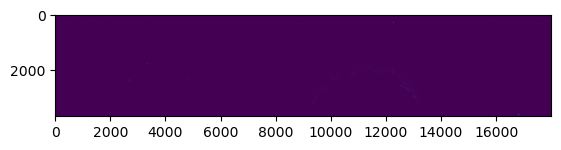

In [7]:
plt.imshow(canvas0)
# plt.savefig('/data/agl_data/NanoFISH/Gabi/GS593_Dppa3_all_mESC_DNA-RNA/20240930_RNA/img.png',dpi=1, bbox_inches='tight', pad_inches=0)

# Add spot coordinates

In [136]:
spots = pd.read_csv(f"/data/agl_data/NanoFISH/Gabi/GS485_Dppa3_all_mESC_RNA-DNA/distances_confocal1.csv")
spots = spots[spots['distance_RNA_um'].notna()]
spots = spots[spots['distance_RNA_um'] <= 5]
# coord_cols = ["x_1","y_1"] # promoter
coord_cols = ["x_RNA","y_RNA"] # RNA
spots = spots.dropna(subset=coord_cols)

In [138]:
import matplotlib.patches as patches

df = df_corrected
images=[]

# Read all images and get dimesnions (tif)
for filepath in df['img']:
    image = imread(filepath)
    image = np.max(image,axis=0)
    images.append(image)

# Add the image sizes to the dataframe
df['height'] = [img.shape[0] for img in images]  # Height of each max projection
df['width'] = [img.shape[1] for img in images]  # Width of each max projection

df['x_px'],df['y_px'] = df['x_global_um'] / (df['pixel_size_x']*1e6), df['y_global_um'] / (df['pixel_size_y']*1e6)
spots['x_px'],spots['y_px'] = spots[coord_cols[0]] / (df['pixel_size_x'][0]*1e6), spots[coord_cols[1]] / (df['pixel_size_y'][0]*1e6)

min_x, min_y =  df['x_px'].min(), df['y_px'].min()

# # Step 2: Convert global coordinates from microns to pixels
df['x_shifted_px'] = (df['x_px'] - min_x).astype(int)
df['y_shifted_px'] = (df['y_px'] - min_y).astype(int)

spots['x_shifted_px'] = (spots['x_px'] - min_x + 0.5*df['height'][0]).astype(int)
spots['y_shifted_px'] = (spots['y_px'] - min_y + 0.5*df['width'][0]).astype(int)

# Step 3: Calculate the canvas size in pixels
# Get the maximum coordinates to define the canvas size
max_x, max_y =  df['x_shifted_px'].max() + df['width'][0], df['y_shifted_px'].max() + df['height'][0]

# Create a blank canvas with shape (y_range, x_range) based on the largest image's dtype
# canvas = np.zeros((max_y, max_x), dtype=images[0].dtype)
canvas0 = np.zeros((max_y, max_x), dtype=images[0].dtype)

# Step 4: Place each image on the canvas at the appropriate shifted coordinates
for idx, (image, x, y) in enumerate(zip(images, df['x_shifted_px'], df['y_shifted_px'])):
    img0 = image
    
    height, width = img0.shape[:2]
    
    x,y = int(x),int(y)

    # Place the image on the canvas (ensure the slices are within bounds)
    canvas0[y:y+height, x:x+width] = img0

In [139]:
def create_square(size):

    # Initialize a square matrix of the given size filled with 0s
    square = np.zeros((size, size), dtype=int)
    # Set the border to 1s
    square[0, :] = 1          # top border
    square[-1, :] = 1         # bottom border
    square[:, 0] = 1          # left border
    square[:, -1] = 1         # right border
    return square

# add sted squares
# spots1 = spots[(spots['x_shifted_px'] > 0) & (spots['y_shifted_px'] > 0)]

# Create a new blank canvas with the same dimensions as canvas0
new_canvas = np.zeros_like(canvas0, dtype=np.uint8)

# Define the square size
square_size = 10  # Adjust as needed

# Remove spots on the very edges
spots = spots[
    (spots['x_shifted_px'] - square_size // 2 >= 0) &
    (spots['x_shifted_px'] + square_size // 2 <= new_canvas.shape[1]) &
    (spots['y_shifted_px'] - square_size // 2 >= 0) &
    (spots['y_shifted_px'] + square_size // 2 <= new_canvas.shape[0])
]

# Iterate through df_sted to add squares
for _, row in spots.iterrows():
    x = int(row['x_shifted_px'])
    y = int(row['y_shifted_px'])

    square = create_square(square_size)

    # new_canvas[int(y_start):int(y_end), int(x_start):int(x_end)] = square
    
    # Set the square region to 1
    new_canvas[int(y-square_size/2):int(y+square_size/2), int(x-square_size/2):int(x+square_size/2)] = square

In [126]:
# projs = [new_canvas]
# rgb_projection = (gray_images_to_rgb_composite(projs,color_names=['magenta','yellow','cyan']) * 255).astype(np.uint8)

In [140]:
tiff.imwrite('/data/agl_data/NanoFISH/Gabi/GS485_Dppa3_all_mESC_RNA-DNA/20240727_DNAFISH/spots_RNA_5um.tiff',new_canvas)

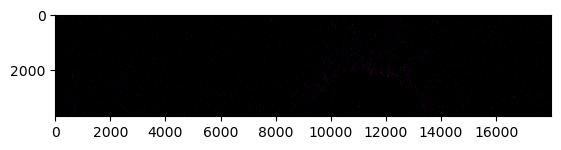

In [55]:
plt.imshow(rgb_projection)

# Add STED squares

In [96]:
in_path = "/data/agl_data/NanoFISH/Gabi/GS485_Dppa3_all_mESC_RNA-DNA/20240727_DNAFISH/"
subdir = "tif"
raw_subpath = "raw"
exclude_string = ""
include_string = "sted"
use_h5_for_metadata = False
global_coordinate_column_names = ['z_global_um', 'y_global_um', 'x_global_um']
stage_directions = np.array([-1, 1, 1])
ch = 0

In [97]:
imgs = glob(f"{in_path}/{subdir}/*.tif")
imgs = natsorted(imgs)
# imgs = [img for img in imgs if exclude_string not in os.path.basename(img)]
imgs = [img for img in imgs if include_string in os.path.basename(img)]

df = pd.DataFrame(imgs,columns=["img"])
sub_dfs = []

for img_path, dfi in df.groupby("img"):

    if use_h5_for_metadata:

        # parse base name (random prefix of files)
        h5_base_name = re.match('(.*?)(_.*?_[0-9]+)+_ch.*', Path(img_path).name).group(1)
        # get acquisition index (field_X_sted_Y), drop underscores not present in H5
        h5_acquisition_name = '_'.join(map(lambda s: s.replace('_', ''), re.findall('_.*?_[0-9]+', Path(img_path).name)))

        # load metadata for current acquisition from corresponding h5 file
        h5_file = h5_base_name + '.h5'
        h5_file = Path(in_path) / raw_subpath / h5_file
        meta = get_scan_field_metadata_h5(h5_file, h5_acquisition_name)

    else:

        # get corresponding msr file
        pattern = '_ch([0-9]+)\.tif'
        # pattern = r'_aligned\.tif$'
        msr_file = re.sub(pattern, '.msr', Path(img_path).name)
        msr_file = Path(in_path) / raw_subpath / msr_file

        # get scan field metadata
        meta = get_scan_field_metadata(msr_file)

    
    # combine offsets, consider z stage direction
    offset = (meta.scan_offset + meta.scan_offset_global
          + stage_directions * (meta.stage_offset + meta.stage_offset_global))
    # Imspector offset is center of image -> to origin of image
    # offset = offset - 1/2 * meta.fov_length

    dfi[global_coordinate_column_names] = offset * 1e6
    dfi['pixel_size_z'] = meta.pixel_size[0]
    dfi['pixel_size_y'] = meta.pixel_size[1]
    dfi['pixel_size_x'] = meta.pixel_size[2]
    dfi['msr'] = msr_file
    sub_dfs.append(dfi)

df_sted = pd.concat(sub_dfs)

In [107]:
import matplotlib.patches as patches

df = df_corrected
images=[]

# Read all images and get dimesnions (tif)
for filepath in df['img']:
    image = imread(filepath)
    image = np.max(image,axis=0)
    images.append(image)

# Add the image sizes to the dataframe
df['height'] = [img.shape[0] for img in images]  # Height of each max projection
df['width'] = [img.shape[1] for img in images]  # Width of each max projection

df['x_px'],df['y_px'] = df['x_global_um'] / (df['pixel_size_x']*1e6), df['y_global_um'] / (df['pixel_size_y']*1e6)
df_sted['x_px'],df_sted['y_px'] = df_sted['x_global_um'] / (df['pixel_size_x'][0]*1e6), df_sted['y_global_um'] / (df['pixel_size_y'][0]*1e6)

min_x, min_y =  df['x_px'].min(), df['y_px'].min()

# # Step 2: Convert global coordinates from microns to pixels
df['x_shifted_px'] = (df['x_px'] - min_x).astype(int)
df['y_shifted_px'] = (df['y_px'] - min_y).astype(int)

df_sted['x_shifted_px'] = (df_sted['x_px'] - min_x + 0.5*df['height'][0]).astype(int)
df_sted['y_shifted_px'] = (df_sted['y_px'] - min_y + 0.5*df['width'][0]).astype(int)

# Step 3: Calculate the canvas size in pixels
# Get the maximum coordinates to define the canvas size
max_x, max_y =  df['x_shifted_px'].max() + df['width'][0], df['y_shifted_px'].max() + df['height'][0]

# Create a blank canvas with shape (y_range, x_range) based on the largest image's dtype
# canvas = np.zeros((max_y, max_x), dtype=images[0].dtype)
canvas0 = np.zeros((max_y, max_x), dtype=images[0].dtype)

# Step 4: Place each image on the canvas at the appropriate shifted coordinates
for idx, (image, x, y) in enumerate(zip(images, df['x_shifted_px'], df['y_shifted_px'])):
    img0 = image
    
    height, width = img0.shape[:2]
    
    x,y = int(x),int(y)

    # Place the image on the canvas (ensure the slices are within bounds)
    canvas0[y:y+height, x:x+width] = img0

In [108]:
def create_square(size):

    # Initialize a square matrix of the given size filled with 0s
    square = np.zeros((size, size), dtype=int)
    # Set the border to 1s
    square[0, :] = 1          # top border
    square[-1, :] = 1         # bottom border
    square[:, 0] = 1          # left border
    square[:, -1] = 1         # right border
    return square

In [115]:
# add sted squares
df_sted1 = df_sted[(df_sted['x_shifted_px'] > 0) & (df_sted['y_shifted_px'] > 0)]

# Create a new blank canvas with the same dimensions as canvas0
new_canvas = np.zeros_like(canvas0, dtype=np.uint8)

# Define the square size
square_size = 10  # Adjust as needed

# Iterate through df_sted to add squares
for _, row in df_sted.iterrows():
    x = int(row['x_shifted_px'])
    y = int(row['y_shifted_px'])

    square = create_square(square_size)

    df_sted = df_sted[
    (df_sted['x_shifted_px'] - square_size // 2 >= 0) &
    (df_sted['x_shifted_px'] + square_size // 2 <= new_canvas.shape[1]) &
    (df_sted['y_shifted_px'] - square_size // 2 >= 0) &
    (df_sted['y_shifted_px'] + square_size // 2 <= new_canvas.shape[0])
    ]
    
    # Set the square region to 1
    new_canvas[int(y-square_size/2):int(y+square_size/2), int(x-square_size/2):int(x+square_size/2)] = square

In [116]:
tiff.imwrite('/data/agl_data/NanoFISH/Gabi/GS485_Dppa3_all_mESC_RNA-DNA/20240727_DNAFISH/sted_squares.tiff',new_canvas)

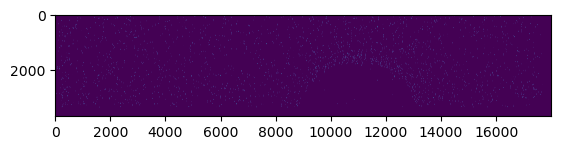

In [295]:
plt.imshow(new_canvas)